# AI-Powered Vehicle Count Prediction - Training Notebook
**Smart City Traffic Management System**

This notebook trains:
1. **YOLOv8** on Indian Vehicle Detection dataset (9 classes)
2. **YOLOv9** and **YOLOv10** for model comparison
3. **LSTM + Attention** for traffic count prediction
4. **Benchmarking** all YOLO models

Run this on **Google Colab with GPU** for fast training.

## Step 1: Check GPU & Install Dependencies

In [1]:
# Check GPU
!nvidia-smi
import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Sat Feb  7 15:19:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install required packages
!pip install ultralytics roboflow supervision deep-sort-realtime fpdf2 scikit-learn plotly -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.6/301.6 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.0 MB/s eta 0:00:00


## Step 2: Download Dataset from Roboflow

In [3]:
from roboflow import Roboflow
import os

# Download Indian Vehicle Detection dataset (9 classes)
rf = Roboflow(api_key="WzAXSzX610sxopHAEBWr")
project = rf.workspace("real-time-vehicle-detection").project("indian-vehicles-detection-n4kya")
dataset = project.version(4)
dataset.download("yolov8", location="/content/dataset_indian")

# Check dataset
for split in ['train', 'valid', 'test']:
    img_dir = f"/content/dataset_indian/{split}/images"
    if os.path.exists(img_dir):
        count = len(os.listdir(img_dir))
        print(f"{split}: {count} images")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset_indian in yolov8:: 100%|██████████| 670/670 [00:00<00:00, 3291.91it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
train: 234 images
valid: 55 images
test: 40 images


In [4]:
# Also download the larger vehicle dataset for additional training
project2 = rf.workspace("roboflow-100").project("vehicles-q0x2v")
dataset2 = project2.version(2)
dataset2.download("yolov8", location="/content/dataset_large")

for split in ['train', 'valid', 'test']:
    img_dir = f"/content/dataset_large/{split}/images"
    if os.path.exists(img_dir):
        count = len(os.listdir(img_dir))
        print(f"{split}: {count} images")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset_large in yolov8:: 100%|██████████| 8128/8128 [00:02<00:00, 3843.44it/s]


train: 2634 images
valid: 966 images
test: 458 images


## Step 3: Train YOLOv8 on Indian Vehicle Dataset

In [5]:
from ultralytics import YOLO

# Load pretrained YOLOv8m
model_v8 = YOLO("yolov8m.pt")

# Train on Indian vehicle dataset
results_v8 = model_v8.train(
    data="/content/dataset_indian/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,  # GPU
    patience=20,
    save=True,
    save_period=10,
    project="/content/training",
    name="yolov8_indian",
    # Augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    # Training params
    optimizer="Adam",
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=3,
)

print("\nYOLOv8 Training Complete!")

Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_indian/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_indian, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=20, pe

In [6]:
# Evaluate YOLOv8 on test set
metrics_v8 = model_v8.val(data="/content/dataset_indian/data.yaml", split="test")
print(f"\n=== YOLOv8 Test Results ===")
print(f"mAP@50:    {metrics_v8.box.map50:.4f}")
print(f"mAP@50-95: {metrics_v8.box.map:.4f}")
print(f"Precision: {metrics_v8.box.mp:.4f}")
print(f"Recall:    {metrics_v8.box.mr:.4f}")

Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 93 layers, 25,844,971 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 29.1±20.3 MB/s, size: 60.2 KB)
val: Scanning /content/dataset_indian/test/labels... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 737.1it/s 0.1s
val: New cache created: /content/dataset_indian/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.7it/s 1.8s
                   all         40         52      0.788      0.783      0.834      0.593
                  Auto          4          6       0.75      0.667      0.737      0.611
                  Bike          2          5          1      0.576      0.846      0.588
                   Bus          5          6          1      0.601      0.822      0.582
                   Car          1          4      0.743       0.75      0.691  

## Step 4: Train YOLOv9

In [7]:
# Train YOLOv9
model_v9 = YOLO("yolov9m.pt")

results_v9 = model_v9.train(
    data="/content/dataset_indian/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    save=True,
    project="/content/training",
    name="yolov9_indian",
    optimizer="Adam",
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=3,
)

# Evaluate
metrics_v9 = model_v9.val(data="/content/dataset_indian/data.yaml", split="test")
print(f"\n=== YOLOv9 Test Results ===")
print(f"mAP@50:    {metrics_v9.box.map50:.4f}")
print(f"mAP@50-95: {metrics_v9.box.map:.4f}")
print(f"Precision: {metrics_v9.box.mp:.4f}")
print(f"Recall:    {metrics_v9.box.mr:.4f}")

Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_indian/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9_indian, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=20, pe

## Step 5: Train YOLOv10

In [8]:
# Train YOLOv10
model_v10 = YOLO("yolov10m.pt")

results_v10 = model_v10.train(
    data="/content/dataset_indian/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    save=True,
    project="/content/training",
    name="yolov10_indian",
    optimizer="Adam",
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=3,
)

# Evaluate
metrics_v10 = model_v10.val(data="/content/dataset_indian/data.yaml", split="test")
print(f"\n=== YOLOv10 Test Results ===")
print(f"mAP@50:    {metrics_v10.box.map50:.4f}")
print(f"mAP@50-95: {metrics_v10.box.map:.4f}")
print(f"Precision: {metrics_v10.box.mp:.4f}")
print(f"Recall:    {metrics_v10.box.mr:.4f}")

Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_indian/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov10_indian, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=20, 

## Step 6: Model Comparison & Benchmarking

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import pandas as pd
import time
import cv2
import numpy as np

# Benchmark all models
results_table = []

models = {
    "YOLOv8m": (model_v8, metrics_v8),
    "YOLOv9m": (model_v9, metrics_v9),
    "YOLOv10m": (model_v10, metrics_v10),
}

# Speed test with dummy image
dummy_img = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)

for name, (model, metrics) in models.items():
    # Measure inference speed
    times = []
    for _ in range(20):
        start = time.time()
        model(dummy_img, verbose=False)
        times.append(time.time() - start)
    avg_time = np.mean(times[5:])  # Skip warmup
    fps = 1.0 / avg_time

    # Model size
    params = sum(p.numel() for p in model.model.parameters()) / 1e6

    results_table.append({
        "Model": name,
        "mAP@50": f"{metrics.box.map50:.4f}",
        "mAP@50-95": f"{metrics.box.map:.4f}",
        "Precision": f"{metrics.box.mp:.4f}",
        "Recall": f"{metrics.box.mr:.4f}",
        "FPS (GPU)": f"{fps:.1f}",
        "Params (M)": f"{params:.1f}",
    })

df_results = pd.DataFrame(results_table)
print("\n" + "="*80)
print("MODEL COMPARISON - Indian Vehicle Detection")
print("="*80)
print(df_results.to_string(index=False))

# Save benchmark results
df_results.to_csv("/content/drive/MyDrive/Vehicle/model_comparison.csv", index=False)
print("\nSaved to /content/drive/MyDrive/Vehicle/model_comparison.csv")


MODEL COMPARISON - Indian Vehicle Detection
   Model mAP@50 mAP@50-95 Precision Recall FPS (GPU) Params (M)
 YOLOv8m 0.8338    0.5935    0.7878 0.7834      39.8       25.8
 YOLOv9m 0.8542    0.5726    0.8637 0.7894      34.6       20.0
YOLOv10m 0.8047    0.5512    0.8038 0.6903      44.3       15.3

Saved to /content/drive/MyDrive/Vehicle/model_comparison.csv


## Step 7: Train LSTM + Attention for Traffic Prediction

In [11]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau


# ─── LSTM + Attention Model ────────────────────────────────────────────
class TrafficLSTM(nn.Module):
    """LSTM with Multi-Head Self-Attention for traffic prediction."""

    def __init__(self, input_size=14, hidden_size=128, num_layers=2,
                 num_heads=4, output_size=6, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.attention = nn.MultiheadAttention(hidden_size, num_heads,
                                              dropout=dropout, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, output_size),
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        out = self.layer_norm(lstm_out + attn_out)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


print("TrafficLSTM model defined.")
model_test = TrafficLSTM()
params = sum(p.numel() for p in model_test.parameters())
print(f"Parameters: {params:,}")

TrafficLSTM model defined.
Parameters: 280,774


In [12]:
# ─── Generate Training Data (realistic Indian traffic patterns) ──────
np.random.seed(42)
DAYS = 90

timestamps = pd.date_range(start="2024-06-01", periods=DAYS * 24, freq="h")
records = []

for ts in timestamps:
    hour = ts.hour
    is_weekend = ts.dayofweek >= 5

    # Indian traffic pattern
    if 0 <= hour < 5: base = 3
    elif 5 <= hour < 7: base = 8
    elif 7 <= hour < 10: base = 30    # Morning peak
    elif 10 <= hour < 12: base = 18
    elif 12 <= hour < 14: base = 22   # Lunch peak
    elif 14 <= hour < 17: base = 16
    elif 17 <= hour < 20: base = 35   # Evening peak
    elif 20 <= hour < 22: base = 15
    else: base = 8

    if is_weekend: base = int(base * 0.6)

    total = max(1, base + np.random.randint(-3, 4))
    car = max(0, int(total * 0.35 + np.random.randint(-1, 2)))
    bike = max(0, int(total * 0.28 + np.random.randint(-1, 2)))
    auto = max(0, int(total * 0.18 + np.random.randint(-1, 2)))
    bus = max(0, int(total * 0.08 + np.random.randint(0, 2)))
    truck = max(0, int(total * 0.11 + np.random.randint(-1, 2)))
    total = car + bike + auto + bus + truck

    # Weather data
    temp = 28 + 5 * np.sin(np.pi * (hour - 6) / 12) + np.random.normal(0, 2)
    humidity = 60 + 15 * np.cos(np.pi * (hour - 14) / 12) + np.random.normal(0, 5)
    rain = np.random.exponential(2) if np.random.random() < 0.3 else 0.0
    visibility = 10.0 - rain * 0.5 + np.random.normal(0, 0.5)
    wind = 5 + np.random.exponential(3)

    records.append({
        "timestamp": ts, "total": total, "car": car, "bus": bus,
        "truck": truck, "auto": auto, "bike": bike,
        "temperature": round(max(15, min(45, temp)), 1),
        "humidity": round(max(20, min(100, humidity)), 1),
        "rain_1h": round(max(0, rain), 2),
        "visibility": round(max(0.5, min(15, visibility)), 1),
        "wind_speed": round(max(0, wind), 1),
    })

df = pd.DataFrame(records)
df.set_index("timestamp", inplace=True)
print(f"Generated {len(df)} hourly records ({DAYS} days)")
print(f"Columns: {list(df.columns)}")
df.head()

Generated 2160 hourly records (90 days)
Columns: ['total', 'car', 'bus', 'truck', 'auto', 'bike', 'temperature', 'humidity', 'rain_1h', 'visibility', 'wind_speed']


,total,car,bus,truck,auto,bike,temperature,humidity,rain_1h,visibility,wind_speed
timestamp,,,,,,,,,,,
2024-06-01 00:00:00,4,0,1,0,1,2,20.6,57.7,1.23,8.9,8.2
2024-06-01 01:00:00,1,0,1,0,0,0,22.3,52.8,0.05,10.7,7.2
2024-06-01 02:00:00,5,1,1,1,0,2,20.7,52.4,0.00,10.6,8.4
2024-06-01 03:00:00,2,1,1,0,0,0,24.3,42.5,2.31,9.3,6.7
2024-06-01 04:00:00,4,0,1,0,1,2,27.1,40.9,0.00,11.4,5.6


In [13]:
# ─── Prepare LSTM Training Data ────────────────────────────────────────
SEQ_LEN = 24       # 24 hours history
PRED_HORIZON = 6   # Predict next 6 hours

# Add cyclical time features
df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)
df["dow_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
df["dow_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 7)

feature_cols = list(df.columns)
print(f"Features ({len(feature_cols)}): {feature_cols}")

# Scale
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df.values)

# Create sliding windows
total_idx = feature_cols.index("total")
X, y = [], []
for i in range(len(scaled) - SEQ_LEN - PRED_HORIZON):
    X.append(scaled[i:i + SEQ_LEN])
    y.append(scaled[i + SEQ_LEN:i + SEQ_LEN + PRED_HORIZON, total_idx])

X, y = np.array(X), np.array(y)
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Split 80/20
split = int(len(X) * 0.8)
X_train, X_val = torch.FloatTensor(X[:split]), torch.FloatTensor(X[split:])
y_train, y_val = torch.FloatTensor(y[:split]), torch.FloatTensor(y[split:])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

print(f"Train: {len(X_train)} samples, Val: {len(X_val)} samples")

Features (15): ['total', 'car', 'bus', 'truck', 'auto', 'bike', 'temperature', 'humidity', 'rain_1h', 'visibility', 'wind_speed', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
X shape: (2130, 24, 15), y shape: (2130, 6)
Train: 1704 samples, Val: 426 samples


In [14]:
# ─── Train LSTM ────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model = TrafficLSTM(
    input_size=len(feature_cols),
    hidden_size=128,
    num_layers=2,
    num_heads=4,
    output_size=PRED_HORIZON,
    dropout=0.2,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=10, factor=0.5)

best_val_loss = float("inf")
train_losses, val_losses = [], []

EPOCHS = 100
for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        pred = model(X_b)
        loss = criterion(pred, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            pred = model(X_b)
            val_loss += criterion(pred, y_b).item()
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/lstm_traffic_predictor.pth")

    if (epoch + 1) % 10 == 0:
        lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1}/{EPOCHS} - Train: {train_loss:.6f} - Val: {val_loss:.6f} - LR: {lr:.6f}")

print(f"\nBest validation loss: {best_val_loss:.6f}")
print("LSTM model saved to /content/lstm_traffic_predictor.pth")

Training on: cuda
Epoch 10/100 - Train: 0.014431 - Val: 0.012581 - LR: 0.001000
Epoch 20/100 - Train: 0.010508 - Val: 0.005919 - LR: 0.001000
Epoch 30/100 - Train: 0.008485 - Val: 0.005182 - LR: 0.001000
Epoch 40/100 - Train: 0.007850 - Val: 0.004402 - LR: 0.001000
Epoch 50/100 - Train: 0.007617 - Val: 0.004532 - LR: 0.001000
Epoch 60/100 - Train: 0.006944 - Val: 0.004269 - LR: 0.000500
Epoch 70/100 - Train: 0.006783 - Val: 0.004254 - LR: 0.000250
Epoch 80/100 - Train: 0.006601 - Val: 0.004321 - LR: 0.000250
Epoch 90/100 - Train: 0.006343 - Val: 0.004155 - LR: 0.000125
Epoch 100/100 - Train: 0.006290 - Val: 0.004142 - LR: 0.000125

Best validation loss: 0.004064
LSTM model saved to /content/lstm_traffic_predictor.pth


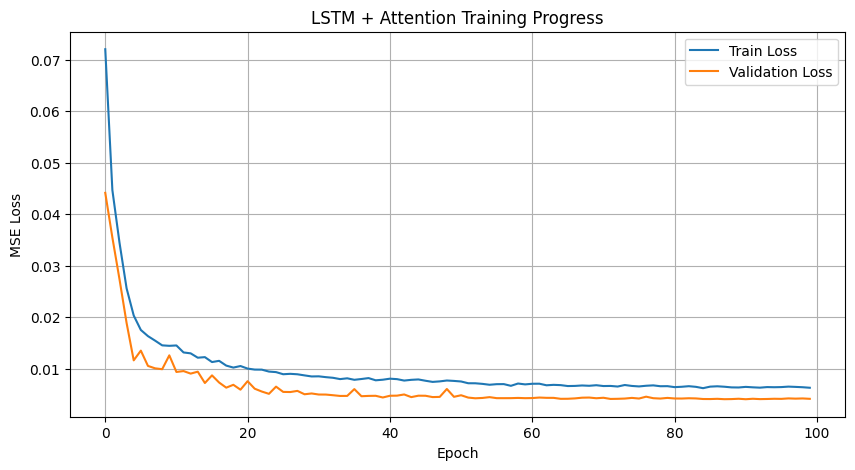

In [15]:
# ─── Plot LSTM Training Loss ───────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM + Attention Training Progress")
plt.legend()
plt.grid(True)
plt.savefig("/content/lstm_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# ─── Test LSTM Prediction ──────────────────────────────────────────────
model.eval()
with torch.no_grad():
    # Use last validation sample
    test_input = X_val[-1:].to(device)
    prediction = model(test_input).cpu().numpy()[0]

# Inverse scale
dummy = np.zeros((PRED_HORIZON, len(feature_cols)))
dummy[:, total_idx] = prediction
pred_counts = scaler.inverse_transform(dummy)[:, total_idx]

# Actual values
actual_scaled = y_val[-1].numpy()
dummy_actual = np.zeros((PRED_HORIZON, len(feature_cols)))
dummy_actual[:, total_idx] = actual_scaled
actual_counts = scaler.inverse_transform(dummy_actual)[:, total_idx]

print("\nPrediction vs Actual (next 6 hours):")
print(f"{'Hour':>6} {'Predicted':>10} {'Actual':>10} {'Error':>10}")
for i in range(PRED_HORIZON):
    error = abs(pred_counts[i] - actual_counts[i])
    print(f"{i+1:>6} {pred_counts[i]:>10.1f} {actual_counts[i]:>10.1f} {error:>10.1f}")

mae = np.mean(np.abs(pred_counts - actual_counts))
print(f"\nMAE: {mae:.2f} vehicles")


Prediction vs Actual (next 6 hours):
  Hour  Predicted     Actual      Error
     1       31.5       32.0        0.5
     2       32.6       34.0        1.4
     3       32.9       33.0        0.1
     4       13.6       16.0        2.4
     5       12.5        8.0        4.5
     6        7.1        5.0        2.1

MAE: 1.85 vehicles


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 8: Download Trained Models

In [20]:
import shutil
import os

# Collect all trained models
os.makedirs("/content/drive/MyDrive/Vehicle/trained_models", exist_ok=True)

# YOLOv8 best weights
v8_best = "/content/training/yolov8_indian/weights/best.pt"
if os.path.exists(v8_best):
    shutil.copy(v8_best, "/content/drive/MyDrive/Vehicle/trained_models/yolov8_best.pt")
    print(f"YOLOv8 best: {os.path.getsize(v8_best)/1024/1024:.1f} MB")

# YOLOv9 best weights
v9_best = "/content/training/yolov9_indian/weights/best.pt"
if os.path.exists(v9_best):
    shutil.copy(v9_best, "/content/drive/MyDrive/Vehicle/trained_models/yolov9_best.pt")
    print(f"YOLOv9 best: {os.path.getsize(v9_best)/1024/1024:.1f} MB")

# YOLOv10 best weights
v10_best = "/content/training/yolov10_indian/weights/best.pt"
if os.path.exists(v10_best):
    shutil.copy(v10_best, "/content/drive/MyDrive/Vehicle/trained_models/yolov10_best.pt")
    print(f"YOLOv10 best: {os.path.getsize(v10_best)/1024/1024:.1f} MB")

# LSTM model
lstm_path = "/content/lstm_traffic_predictor.pth"
if os.path.exists(lstm_path):
    shutil.copy(lstm_path, "/content/drive/MyDrive/Vehicle/trained_models/lstm_traffic_predictor.pth")
    print(f"LSTM model: {os.path.getsize(lstm_path)/1024:.1f} KB")

# Benchmark CSV
shutil.copy("/content/drive/MyDrive/Vehicle/model_comparison.csv", "/content/drive/MyDrive/Vehicle/trained_models/model_comparison.csv")

# Zip all models for download
shutil.make_archive("/content/trained_models", "zip", "/content/drive/MyDrive/Vehicle/trained_models")
print(f"\nAll models zipped: /content/drive/MyDrive/Vehicle/trained_models.zip")
print("Download this file and extract to f:/vehical/models/")

YOLOv8 best: 49.6 MB
YOLOv9 best: 39.0 MB
YOLOv10 best: 31.9 MB
LSTM model: 1104.2 KB

All models zipped: /content/drive/MyDrive/Vehicle/trained_models.zip
Download this file and extract to f:/vehical/models/


In [21]:
# Download from Colab
from google.colab import files
files.download("/content/trained_models.zip")
files.download("/content/model_comparison.csv")
files.download("/content/lstm_training_loss.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: /content/model_comparison.csv

## Step 9: After Download - Copy to Project

After downloading `trained_models.zip`, extract and copy files to your local project:

```
f:/vehical/models/yolov8/best.pt    <- yolov8_best.pt
f:/vehical/models/yolov9/best.pt    <- yolov9_best.pt
f:/vehical/models/yolov10/best.pt   <- yolov10_best.pt
f:/vehical/models/lstm/traffic_predictor.pth  <- lstm_traffic_predictor.pth
f:/vehical/outputs/benchmarks/model_comparison.csv  <- model_comparison.csv
```

Then run the dashboard:
```bash
cd f:/vehical
streamlit run dashboard/app.py
```